In [1]:
pip install librosa matplotlib scipy


In [2]:
https://github.com/Monesri/audio-frequency-comparision/raw/refs/heads/main/audio1.wav

SyntaxError: invalid syntax (ipython-input-1181827245.py, line 1)

In [4]:
https://github.com/Monesri/audio-frequency-comparision/raw/refs/heads/main/audio2.wav

SyntaxError: invalid syntax (ipython-input-158114465.py, line 1)

In [6]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine
import urllib.request

# URLs from your GitHub "View raw"
url1 = "https://github.com/Monesri/audio-frequency-comparision/raw/refs/heads/main/audio1.wav"
url2 = "https://github.com/Monesri/audio-frequency-comparision/raw/refs/heads/main/audio2.wav"

# Download audio files to Colab
urllib.request.urlretrieve(url1, "audio1.wav")
urllib.request.urlretrieve(url2, "audio2.wav")

# Load audio
y1, sr1 = librosa.load("audio1.wav", sr=None, mono=True)
y2, sr2 = librosa.load("audio2.wav", sr=None, mono=True)

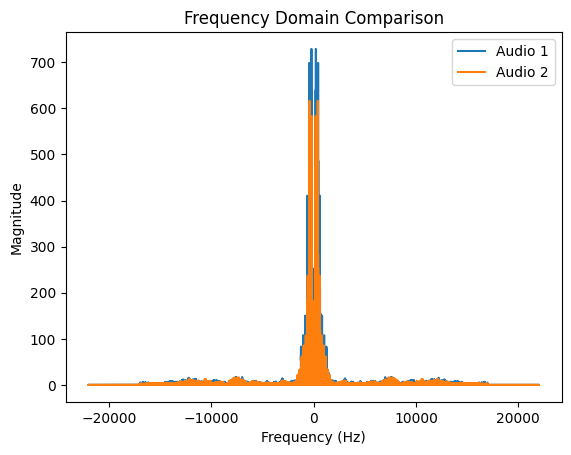

Voice Similarity Score: 0.99925715


In [7]:
# Make same length
min_len = min(len(y1), len(y2))
y1 = y1[:min_len]
y2 = y2[:min_len]

# FFT (Frequency-domain)
fft1 = np.abs(np.fft.fft(y1))
fft2 = np.abs(np.fft.fft(y2))
freqs = np.fft.fftfreq(len(fft1), 1/sr1)

# Plot frequency-domain graph
plt.figure()
plt.plot(freqs, fft1, label="Audio 1")
plt.plot(freqs, fft2, label="Audio 2")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Frequency Domain Comparison")
plt.legend()
plt.show()

# MFCC features and similarity
mfcc1 = librosa.feature.mfcc(y=y1, sr=sr1, n_mfcc=13)
mfcc2 = librosa.feature.mfcc(y=y1, sr=sr1, n_mfcc=13)
mfcc2 = librosa.feature.mfcc(y=y2, sr=sr2, n_mfcc=13)
mfcc1_mean = np.mean(mfcc1, axis=1)
mfcc2_mean = np.mean(mfcc2, axis=1)
similarity = 1 - cosine(mfcc1_mean, mfcc2_mean)
print("Voice Similarity Score:", similarity)